<a href="https://colab.research.google.com/github/Suryansh763/Euro-Finals-2024/blob/main/2024_Euro_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#installing relevant packages
!pip install statsbombpy
!pip install mplsoccer
!pip install highlight_text

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.5 MB/s eta 0:00:00


In [ ]:
#import the packages
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch, Pitch
from highlight_text import ax_text, fig_text
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns

Loading all the competitions, match and event data from StatsBomb (statsbombpy)

In [ ]:
#Calling statsbomb API to get all free competitions on statsbomb
free_comp = sb.competitions()

#Printing the list of all free competitons available
free_comp

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
70,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2024-02-12T14:45:05.702250,2021-06-13T16:17:31.694,None,2024-02-12T14:45:05.702250
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263
73,72,107,International,Women's World Cup,female,False,True,2023,2025-07-14T10:07:06.620906,2025-07-14T10:10:27.224586,2025-07-14T10:10:27.224586,2025-07-14T10:07:06.620906


In [ ]:
#Now find the competition I want to use to analyze
#Using Euro 2024; first find if it's there
#Euro 2024 competition id, season id
#competition_id=55, season_id=282

euro_2024_matches = sb.matches(competition_id=55, season_id=282)

#print the first 5 matches listed
euro_2024_matches.head(5)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3942819,2024-07-10,22:00:00.000,Europe - UEFA Euro,2024,Netherlands,England,1,2,available,...,2024-07-15T07:57:36.684453,6,Semi-finals,Signal-Iduna-Park,Felix Zwayer,Ronald Koeman,Gareth Southgate,1.1.0,2,2
1,3943043,2024-07-14,22:00:00.000,Europe - UEFA Euro,2024,Spain,England,2,1,available,...,2024-07-15T15:52:24.778809,7,Final,Olympiastadion Berlin,François Letexier,Luis de la Fuente Castillo,Gareth Southgate,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,Europe - UEFA Euro,2024,Spain,France,2,1,available,...,2024-07-10T13:01:26.597509,6,Semi-finals,Allianz Arena,Slavko Vinčić,Luis de la Fuente Castillo,Didier Deschamps,1.1.0,2,2
3,3942382,2024-07-06,22:00:00.000,Europe - UEFA Euro,2024,Netherlands,Turkey,2,1,available,...,2024-07-10T06:56:35.146850,5,Quarter-finals,Olympiastadion Berlin,Clément Turpin,Ronald Koeman,Vincenzo Montella,1.1.0,2,2
4,3942349,2024-07-05,22:00:00.000,Europe - UEFA Euro,2024,Portugal,France,0,0,available,...,2024-07-12T02:00:16.871522,5,Quarter-finals,Volksparkstadion,Michael Oliver,Roberto Martínez Montoliú,Didier Deschamps,1.1.0,2,2


In [ ]:
#Analysing the Final, Spain vs England
#create variable for the team you want to look into, starting with spain
team = "Spain"

#filter for only matches that the focus team played in
matches_df = euro_2024_matches[(euro_2024_matches['home_team'] == team)|(euro_2024_matches['away_team'] == team)]

#sort by match date to get the most recent match
matches_df=matches_df.sort_values(by='match_date', ascending=False)

In [ ]:
matches_df.head(5)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
1,3943043,2024-07-14,22:00:00.000,Europe - UEFA Euro,2024,Spain,England,2,1,available,...,2024-07-15T15:52:24.778809,7,Final,Olympiastadion Berlin,François Letexier,Luis de la Fuente Castillo,Gareth Southgate,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,Europe - UEFA Euro,2024,Spain,France,2,1,available,...,2024-07-10T13:01:26.597509,6,Semi-finals,Allianz Arena,Slavko Vinčić,Luis de la Fuente Castillo,Didier Deschamps,1.1.0,2,2
8,3942226,2024-07-05,19:00:00.000,Europe - UEFA Euro,2024,Spain,Germany,2,1,available,...,2024-07-13T03:52:43.383929,5,Quarter-finals,MHPArena,Anthony Taylor,Luis de la Fuente Castillo,Julian Nagelsmann,1.1.0,2,2
15,3941018,2024-06-30,22:00:00.000,Europe - UEFA Euro,2024,Spain,Georgia,4,1,available,...,2024-07-12T06:08:12.572176,4,Round of 16,RheinEnergieStadion,François Letexier,Luis de la Fuente Castillo,Willy Sagnol,1.1.0,2,2
18,3930179,2024-06-24,22:00:00.000,Europe - UEFA Euro,2024,Albania,Spain,0,1,available,...,2024-07-01T06:07:22.418137,3,Group Stage,Merkur Spiel-Arena,Glenn Nyberg,Sylvio Mendes Campos Junior,Luis de la Fuente Castillo,1.1.0,2,2


In [ ]:
#create a variable containing the first match id in the data frame
final_match = matches_df[matches_df["competition_stage"] == "Final"]

latest_match_id = final_match.match_id.iloc[0]
print(latest_match_id)

3943043


In [ ]:
#call the statsbombpy events API to bring in the event data for the match
events_df = sb.events(match_id=latest_match_id)

#print the first 5 rows of data/events
events_df.head(3)

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN


In [ ]:
#Printing all columns in the events table
events_df.columns

Index(['50_50', 'ball_receipt_outcome', 'ball_recovery_recovery_failure',
       'block_deflection', 'block_offensive', 'block_save_block',
       'carry_end_location', 'clearance_aerial_won', 'clearance_body_part',
       'clearance_head', 'clearance_left_foot', 'clearance_right_foot',
       'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun',
       'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive', 'foul_won_advantage',
       'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location',
       'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique',
       'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain',
       'interception_outcome', 'location', 'match_id', 'minute', 'off_camera',
       'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id',
       'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_end_location',
       'pass_goal_assist

In [ ]:
events_df.pass_outcome.head(5)

,pass_outcome
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [ ]:
#Using the cordinates to seprate the start and end location
events_df[['x', 'y']] = events_df['location'].apply(pd.Series)
events_df[["pass_end_x","pass_end_y"]] = events_df['pass_end_location'].apply(pd.Series)
events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(pd.Series)

## **Exmaple 1: Passes and Dribbles into final third** 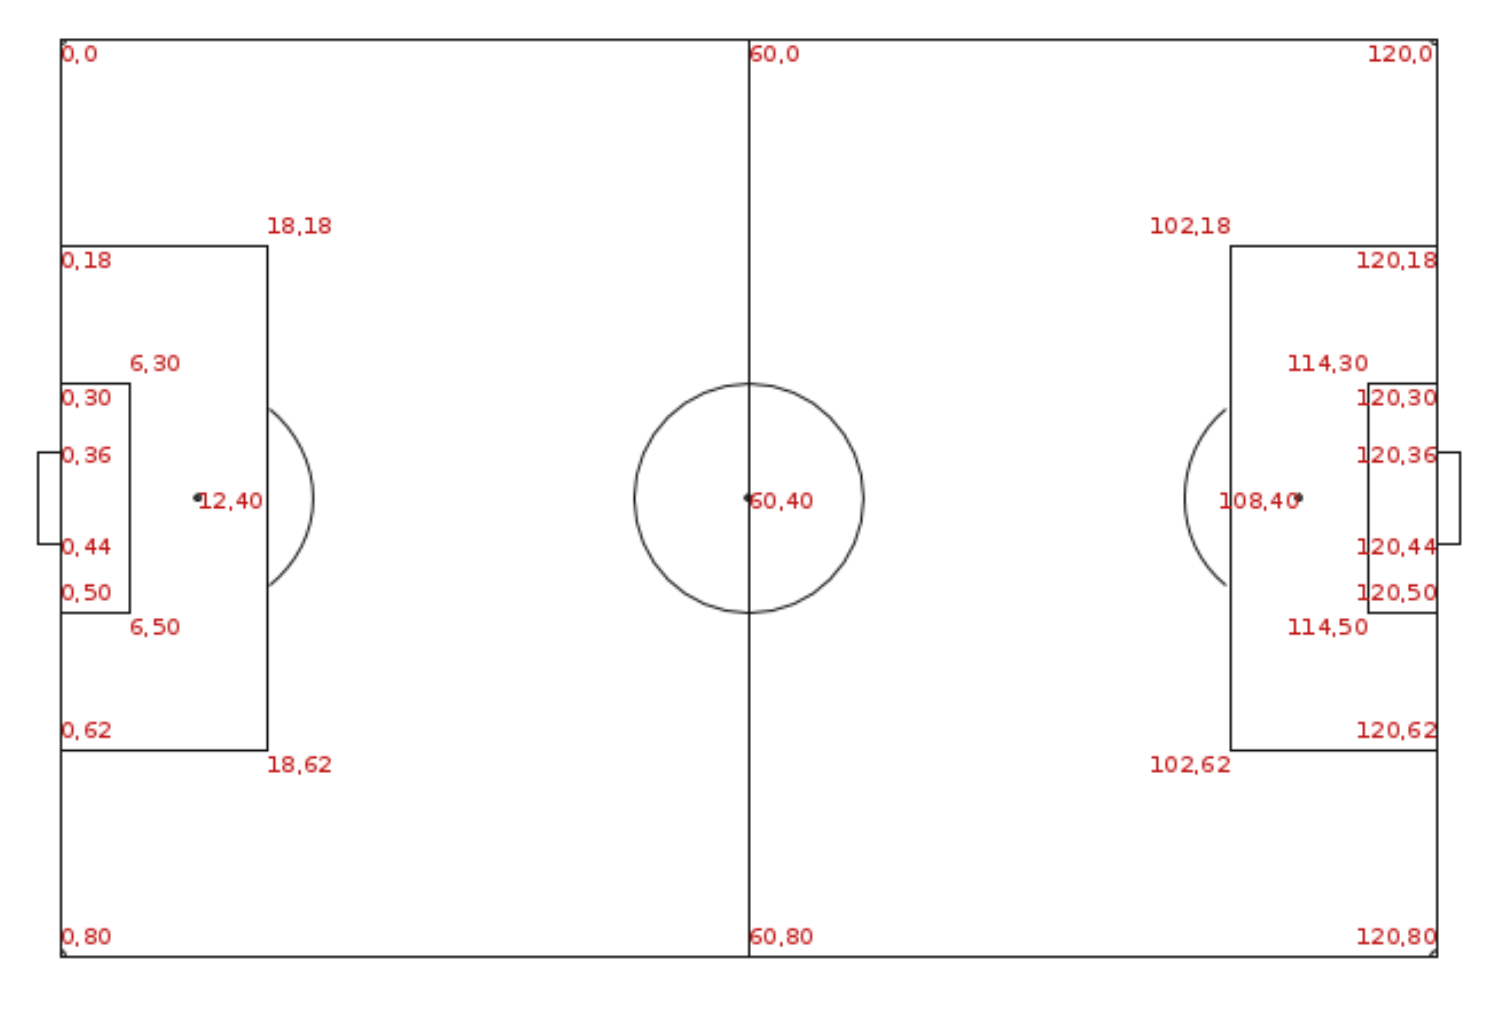

In [ ]:
#Find all the possible pass and dribble outcomes
events_df.pass_outcome.unique()

array([nan, 'Out', 'Incomplete', 'Unknown', 'Pass Offside'], dtype=object)

In [ ]:
#filter for events done by the focus team
#filter by event type to get only passes
#filter for passes that started outside of the final third
#filter for passes that ended in the final third
#filter for completed passes
f3rd_passes=events_df[(events_df.team==team)&(events_df.type=="Pass")&(events_df.x<120)&(events_df.pass_end_x>90)&(events_df.pass_outcome.isna())]

#get count for each player
f3rd_passes_count=f3rd_passes.groupby('player').size().reset_index()

In [ ]:
f3rd_passes_count

,player,0
0,Aymeric Laporte,6
1,Daniel Carvajal Ramos,13
2,Daniel Olmo Carvajal,10
3,Fabián Ruiz Peña,10
4,Lamine Yamal Nasraoui Ebana,9
5,Marc Cucurella Saseta,3
6,Martín Zubimendi Ibáñez,4
7,Mikel Oyarzabal Ugarte,1
8,Nicholas Williams Arthuer,12
9,Robin Aime Robert Le Normand,1


In [ ]:
#rename second column
f3rd_passes_count.rename(columns={f3rd_passes_count.columns[1]: "Passes" }, inplace = True)


In [ ]:
f3rd_passes_count

,player,Passes
0,Aymeric Laporte,6
1,Daniel Carvajal Ramos,13
2,Daniel Olmo Carvajal,10
3,Fabián Ruiz Peña,10
4,Lamine Yamal Nasraoui Ebana,9
5,Marc Cucurella Saseta,3
6,Martín Zubimendi Ibáñez,4
7,Mikel Oyarzabal Ugarte,1
8,Nicholas Williams Arthuer,12
9,Robin Aime Robert Le Normand,1


In [ ]:
#get final third carries for focus team
f3rd_carries=events_df[(events_df.type=="Carry")&(events_df.x<120)&(events_df.carry_end_x>90)&(events_df.team==team)]

#get count for each player
f3rd_carries_count=f3rd_carries.groupby('player').size().reset_index()

#rename second column
f3rd_carries_count.rename(columns={f3rd_carries_count.columns[1]: "Carries" }, inplace = True)

In [ ]:
f3rd_carries_count

,player,Carries
0,Daniel Carvajal Ramos,10
1,Daniel Olmo Carvajal,12
2,Fabián Ruiz Peña,7
3,Lamine Yamal Nasraoui Ebana,14
4,Marc Cucurella Saseta,7
5,Martín Zubimendi Ibáñez,1
6,Mikel Oyarzabal Ugarte,1
7,Nicholas Williams Arthuer,25
8,Álvaro Borja Morata Martín,3


In [ ]:
#combine dataframes
progressions_df=pd.merge(f3rd_passes_count, f3rd_carries_count,
                    how="outer", on=["player"])

In [ ]:
progressions_df

,player,Passes,Carries
0,Aymeric Laporte,6.0,NaN
1,Daniel Carvajal Ramos,13.0,10.0
2,Daniel Olmo Carvajal,10.0,12.0
3,Fabián Ruiz Peña,10.0,7.0
4,Lamine Yamal Nasraoui Ebana,9.0,14.0
5,Marc Cucurella Saseta,3.0,7.0
6,Martín Zubimendi Ibáñez,4.0,1.0
7,Mikel Oyarzabal Ugarte,1.0,1.0
8,Nicholas Williams Arthuer,12.0,25.0
9,Robin Aime Robert Le Normand,1.0,NaN


In [ ]:
#add 0 where value is NaN
progressions_df=progressions_df.fillna(0)

In [ ]:
progressions_df

,player,Passes,Carries
0,Aymeric Laporte,6.0,0.0
1,Daniel Carvajal Ramos,13.0,10.0
2,Daniel Olmo Carvajal,10.0,12.0
3,Fabián Ruiz Peña,10.0,7.0
4,Lamine Yamal Nasraoui Ebana,9.0,14.0
5,Marc Cucurella Saseta,3.0,7.0
6,Martín Zubimendi Ibáñez,4.0,1.0
7,Mikel Oyarzabal Ugarte,1.0,1.0
8,Nicholas Williams Arthuer,12.0,25.0
9,Robin Aime Robert Le Normand,1.0,0.0


In [ ]:
#add a new column with the total
progressions_df['total']=progressions_df['Passes']+progressions_df['Carries']

In [ ]:
progressions_df

,player,Passes,Carries,total
0,Aymeric Laporte,6.0,0.0,6.0
1,Daniel Carvajal Ramos,13.0,10.0,23.0
2,Daniel Olmo Carvajal,10.0,12.0,22.0
3,Fabián Ruiz Peña,10.0,7.0,17.0
4,Lamine Yamal Nasraoui Ebana,9.0,14.0,23.0
5,Marc Cucurella Saseta,3.0,7.0,10.0
6,Martín Zubimendi Ibáñez,4.0,1.0,5.0
7,Mikel Oyarzabal Ugarte,1.0,1.0,2.0
8,Nicholas Williams Arthuer,12.0,25.0,37.0
9,Robin Aime Robert Le Normand,1.0,0.0,1.0


In [ ]:
progressions_df.sort_values(by='total', ascending=False, inplace=True)

In [ ]:
progressions_df

,player,Passes,Carries,total
8,Nicholas Williams Arthuer,12.0,25.0,37.0
1,Daniel Carvajal Ramos,13.0,10.0,23.0
4,Lamine Yamal Nasraoui Ebana,9.0,14.0,23.0
2,Daniel Olmo Carvajal,10.0,12.0,22.0
3,Fabián Ruiz Peña,10.0,7.0,17.0
5,Marc Cucurella Saseta,3.0,7.0,10.0
0,Aymeric Laporte,6.0,0.0,6.0
6,Martín Zubimendi Ibáñez,4.0,1.0,5.0
10,Rodrigo Hernández Cascante,4.0,0.0,4.0
11,Álvaro Borja Morata Martín,0.0,3.0,3.0


**Visualization**

<Figure size 1500x1500 with 0 Axes>

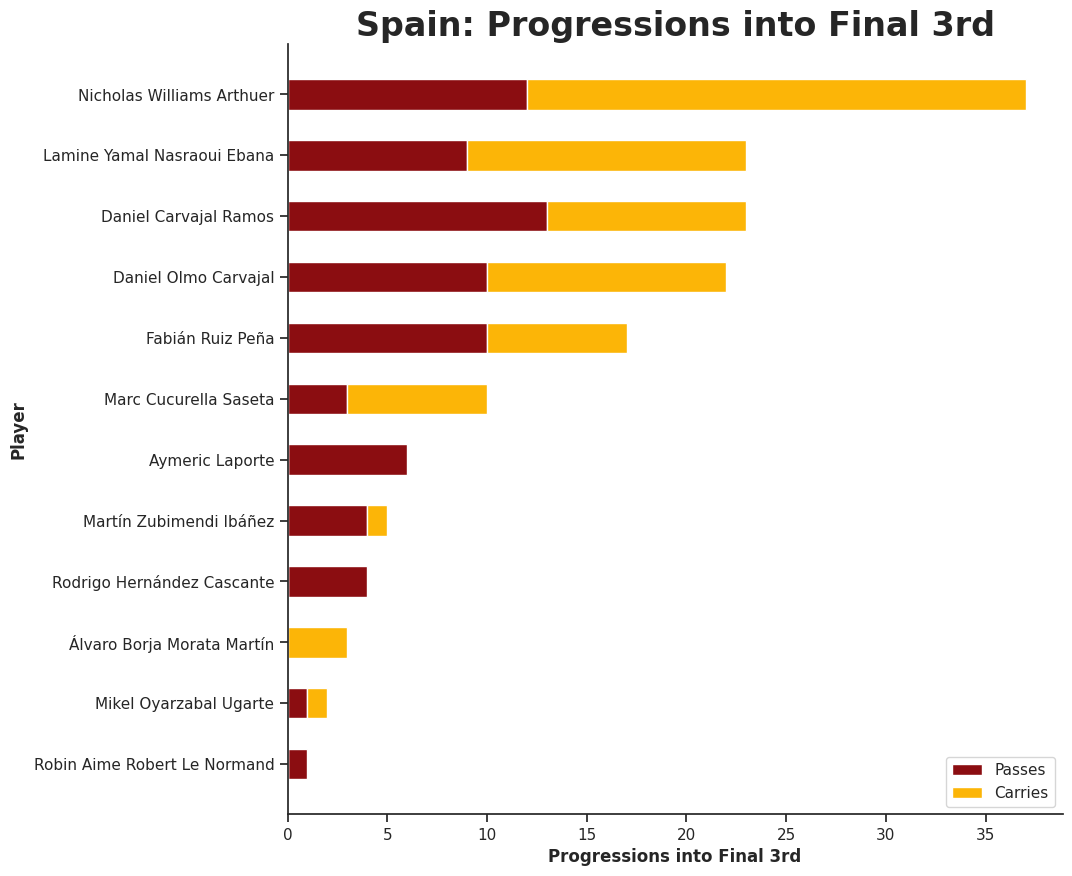

In [ ]:
#create stacked bar chart
pass_colour='#8B0D11'
carry_colour='#FCB507'

#sort to get lowest values first (so that it plots in the correct order on our bar chart)
progressions_df.sort_values(by='total', ascending=True, inplace=True)

#include only relevant columns
barchart_df=progressions_df[["player", "Passes", "Carries"]]


#create figure and set some style parameters
plt.figure(figsize = (15,15))
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
sns.set_style("ticks")

#create bar chart
barchart_df.set_index('player').plot(kind='barh', stacked=True,color=[pass_colour, carry_colour],legend=True,figsize=(10,10))

#add chart labels and title
plt.xlabel(xlabel="Progressions into Final 3rd",fontdict = { 'fontsize': 12, 'weight':'semibold'})
plt.ylabel(ylabel="Player",fontdict = { 'fontsize': 12, 'weight':'semibold'})
plt.title(f"{team}: Progressions into Final 3rd",fontdict = { 'fontsize': 24, 'weight':'bold'})

#keep two axes
sns.despine(top=True, right=True, left=False, bottom=False)
plt.autoscale()
plt.show()

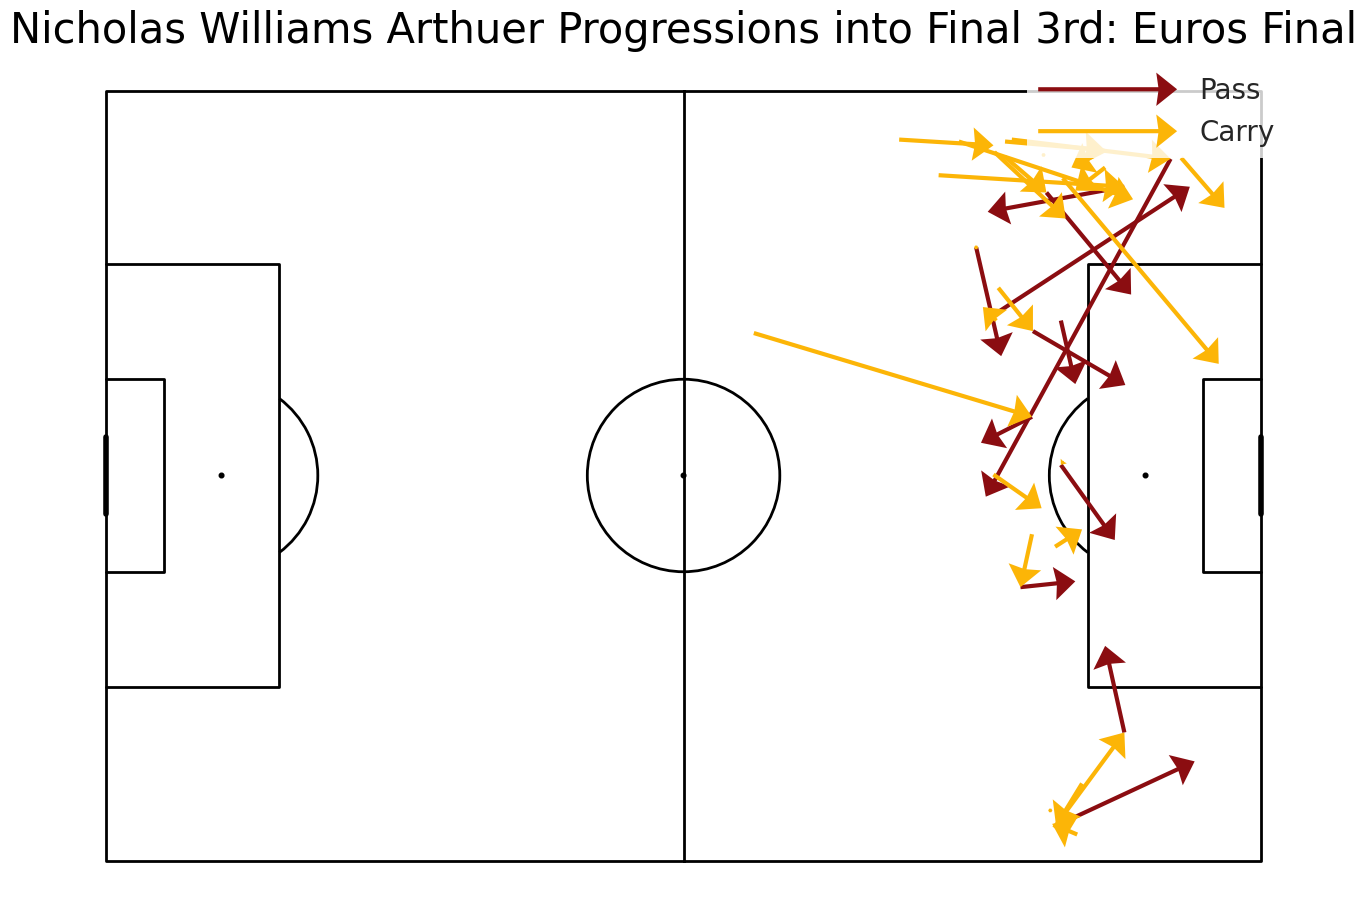

In [ ]:
#visualise for a given player
player_name="Nicholas Williams Arthuer"

player_passes=f3rd_passes[(f3rd_passes.player==player_name)]
player_carries=f3rd_carries[(f3rd_carries.player==player_name)]

#set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_zorder=2, line_color='black')
fig, ax = pitch.draw(figsize=(16, 11),constrained_layout=True, tight_layout=False)
fig.set_facecolor('white')

#plot the passes
pitch.arrows(player_passes.x, player_passes.y,
player_passes.pass_end_x, player_passes.pass_end_y, width=3,
headwidth=8, headlength=5, color=pass_colour, ax=ax, zorder=2, label = "Pass")

#plot the carries
pitch.arrows(player_carries.x, player_carries.y,
player_carries.carry_end_x, player_carries.carry_end_y, width=3,
headwidth=8, headlength=5, color=carry_colour, ax=ax, zorder=2, label = "Carry")

#plot the legend
ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=20, loc='best')

#set title of viz
ax_title = ax.set_title(f'{player_name} Progressions into Final 3rd: Euros Final', fontsize=30,color='black')

**Touch Maps**

In [ ]:
player1="Nicholas Williams Arthuer"
player2="Lamine Yamal Nasraoui Ebana"
touches=['Pass', 'Ball Receipt*', 'Carry', 'Clearance', 'Foul Won', 'Block',
'Ball Recovery', 'Duel', 'Dribble', 'Interception', 'Miscontrol', 'Shot']

In [ ]:
player1_df=events_df[(events_df.player==player1)&(events_df.type.isin(touches))]
player2_df=events_df[(events_df.player==player2)&(events_df.type.isin(touches))]

In [ ]:
#create colour map
colour1="white"
colour2="#c3c3c3"
colour3="#e21017"
cmaplist = [colour1, colour2, colour3]
cmap = LinearSegmentedColormap.from_list("", cmaplist)

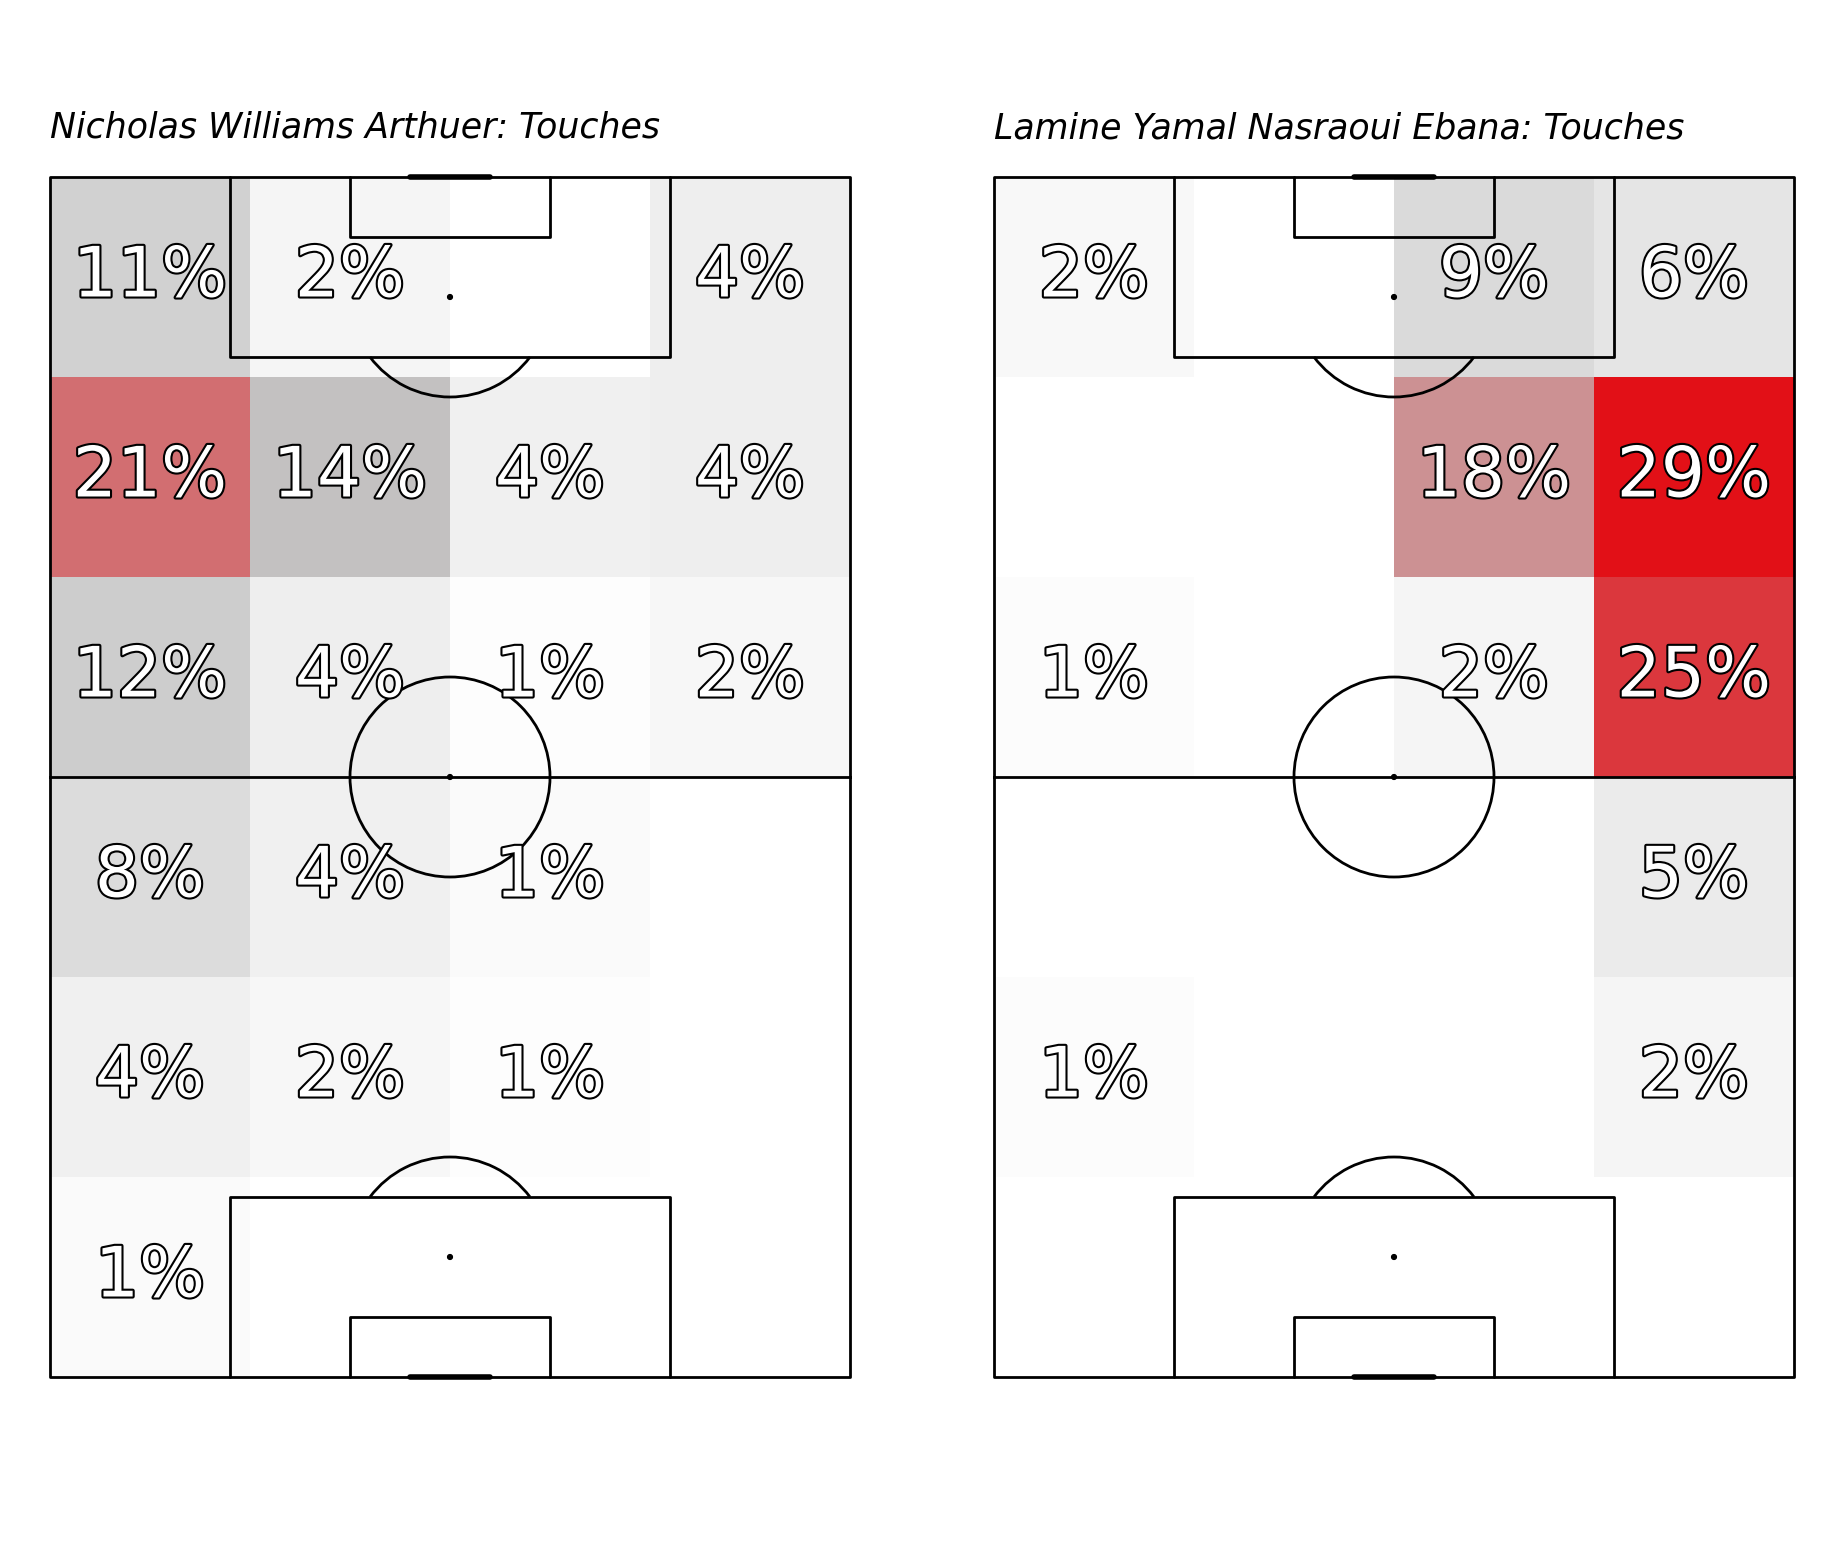

In [ ]:
path_eff = [path_effects.Stroke(linewidth=3, foreground='black'),
            path_effects.Normal()]

#create a grid of pitches
#define pitch style
pitch = VerticalPitch(pitch_type='statsbomb', line_zorder=2, line_color='#000000', linewidth=2,half=False)

#create a grid - in this example, one row of two pitches
fig, axs = pitch.grid(nrows=1, ncols=2
                      ,figheight=16,
                      grid_width=0.65,
                      endnote_height=0.03, endnote_space=0.05,
                      axis=False,title_space=0.02, title_height=0.06, grid_height=0.8)

#get data for heatmap
#player1
bin_statistic1 = pitch.bin_statistic(player1_df.x, player1_df.y, statistic='count',
bins=(6, 4),normalize=True)
#player2
bin_statistic2 = pitch.bin_statistic(player2_df.x, player2_df.y, statistic='count',
bins=(6, 4),normalize=True)

#calculate vmax value
#we want both our heatmaps to use the same colour spectrum
vmax1=bin_statistic1['statistic'].max()
vmax2=bin_statistic2['statistic'].max()

if vmax1>vmax2:
  vmax=vmax1
else:
  vmax=vmax2

#set vmin as zero
vmin=0

#plot heatmap for player1
heatmap1 = pitch.heatmap(bin_statistic1, ax=axs['pitch'][0], cmap=cmap, vmax=vmax, vmin=vmin)

#add percentages for each zone
annotate1 = pitch.label_heatmap(bin_statistic1, color='white',
                                path_effects=path_eff, fontsize=50, ax=axs['pitch'][0],
                                str_format='{:.0%}',
                                ha='center', va='center',
                                exclude_zeros=True)

#add name of player to the top of the heatmap
ax_text(0, 125, f'{player1}: Touches', ha='left', c='black',va='center', fontsize=25,ax=axs['pitch'][0],style='italic')


#plot heatmap for player2
heatmap2 = pitch.heatmap(bin_statistic2, ax=axs['pitch'][1], cmap=cmap, vmax=vmax, vmin=vmin)

#add percentages for each zone
annotate2 = pitch.label_heatmap(bin_statistic2, color='white',
                                path_effects=path_eff, fontsize=50, ax=axs['pitch'][1],
                                str_format='{:.0%}',
                                ha='center', va='center',
                                exclude_zeros=True)

#add name of player to the top of the heatmap
ax_text(0, 125, f'{player2}: Touches', ha='left', c='black',va='center', fontsize=25,ax=axs['pitch'][1],style='italic')

**Getting xG**

In [ ]:
# get event data for entire season
comp_events_df=sb.competition_events(
     country='Europe',
     division='UEFA Euro',
     season='2024',
     gender="male")

In [ ]:
comp_events_df[['x', 'y']] = comp_events_df['location'].apply(pd.Series)
comp_events_df[['pass_end_x', 'pass_end_y']] = comp_events_df['pass_end_location'].apply(pd.Series)
comp_events_df[['carry_end_x', 'carry_end_y']] = comp_events_df['carry_end_location'].apply(pd.Series)

/tmp/ipython-input-2447140862.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  comp_events_df[['x', 'y']] = comp_events_df['location'].apply(pd.Series)
/tmp/ipython-input-2447140862.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  comp_events_df[['x', 'y']] = comp_events_df['location'].apply(pd.Series)
/tmp/ipython-input-2447140862.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usin

In [ ]:
# get non penalty shots and non penalty goals
shots_df=comp_events_df[(comp_events_df.type=="Shot")&(comp_events_df.shot_type!="Penalty")]
goals_df=comp_events_df[(comp_events_df.type=="Shot")&(comp_events_df.shot_type!="Penalty")&(comp_events_df.shot_outcome=="Goal")]

#shots
#get count for each player, include team info
shots_count=shots_df.groupby(['player','team']).size().reset_index()

#rename second column
shots_count.rename(columns={shots_count.columns[2]: "np Shots" }, inplace = True)

#goals
#get count for each player, include team info
goals_count=goals_df.groupby(['player', 'team']).size().reset_index()

#rename second column
goals_count.rename(columns={goals_count.columns[2]: "np Goals" }, inplace = True)

#xG
#get count for each player, include team info
xg_sum=shots_df.groupby(['player', 'team'])['shot_statsbomb_xg'].sum().reset_index()

#rename second column
xg_sum.rename(columns={xg_sum.columns[2]: "np xG" }, inplace = True)

#round up to 2 decimal places
xg_sum['np xG']=xg_sum['np xG'].round(2)

In [ ]:
#combine dataframes
shot_stats=pd.merge(shots_count, goals_count,
                    how="outer", on=["player", "team"])

shot_stats=pd.merge(shot_stats, xg_sum,
                    how="outer", on=["player", "team"])

In [ ]:
#add 0 where value is NaN
shot_stats=shot_stats.fillna(0)

#sort to get top goalscorers, change by=' ' to get top xG, or top Shots
shot_stats=shot_stats.sort_values(by='np xG', ascending=False)

In [ ]:
shot_stats.head(10)

,player,team,np Shots,np Goals,np xG
109,Harry Kane,England,17,2.0,2.27
154,Kai Havertz,Germany,17,0.0,2.21
56,Cristiano Ronaldo dos Santos Aveiro,Portugal,22,0.0,2.19
206,Memphis Depay,Netherlands,18,1.0,1.95
276,Romelu Lukaku Menama,Belgium,11,0.0,1.75
171,Kylian Mbappé Lottin,France,23,0.0,1.72
173,Lamine Yamal Nasraoui Ebana,Spain,18,1.0,1.59
42,Breel-Donald Embolo,Switzerland,8,2.0,1.57
329,Álvaro Borja Morata Martín,Spain,14,1.0,1.57
53,Christoph Baumgartner,Austria,8,1.0,1.55


In [ ]:
#Shot map for top scorer
xg_player=shot_stats.player.iloc[0]

player_goals_df=goals_df[(goals_df.player==xg_player)]

player_shots_df=shots_df[(shots_df.player==xg_player)&(shots_df.shot_outcome!="Goal")]

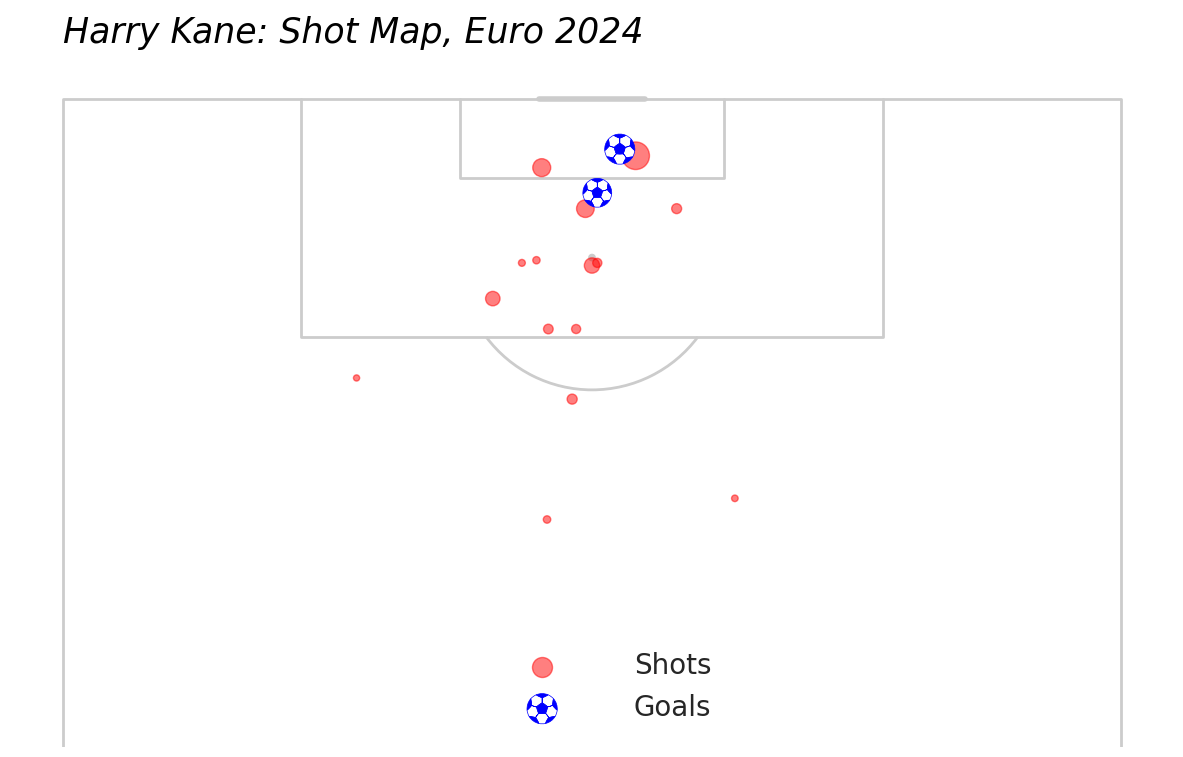

In [ ]:
pitch = VerticalPitch(pitch_type='statsbomb',half=True,pad_bottom=-11)
fig, ax = pitch.draw(figsize=(12, 10))

shot_colour='red'
goal_colour='blue'

shots = pitch.scatter(player_shots_df.x, player_shots_df.y,
#make size relative to xG value
s=player_shots_df.shot_statsbomb_xg*1000,
c=shot_colour,
label='Shots',
marker='o',
alpha=0.5,
ax=ax)

goals = pitch.scatter(player_goals_df.x, player_goals_df.y,
#make size relative to xG value
s=player_goals_df.shot_statsbomb_xg*1000,
c='white',
edgecolors=goal_colour,
label='Goals',
marker='football',
ax=ax)

#plot the legend
ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=20, loc='best')

ax_text(0, 125, f'{xg_player}: Shot Map, Euro 2024', ha='left', c='black',va='center', fontsize=25,ax=ax,style='italic')

In [ ]:
#Cummulative xG over 90mins between Spain and England
shots_df = events_df[events_df["type"] == "Shot"].copy()
shots_df["match_time"] = shots_df["minute"] + shots_df["second"] / 60
shots_df["cumulative_xg"] = shots_df.groupby("team")["shot_statsbomb_xg"].cumsum()

goals_df = shots_df[shots_df["shot_outcome"] == "Goal"].copy()

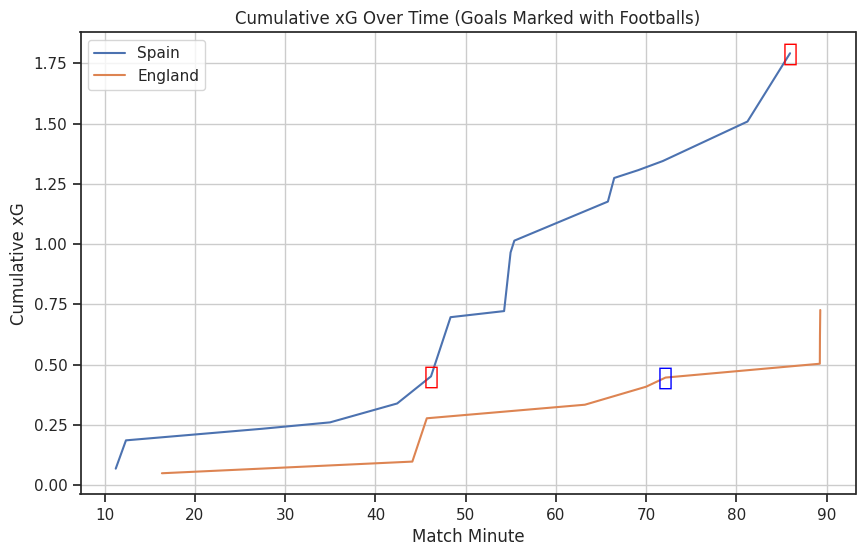

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Plot cumulative xG (already computed earlier)
for team in shots_df["team"].unique():
    team_data = shots_df[shots_df["team"] == team]
    plt.plot(team_data["match_time"], team_data["cumulative_xg"], label=team)

# Football markers for goals
for _, row in goals_df.iterrows():
    color = "red" if row["team"] == "Spain" else "blue"

    plt.text(
        row["match_time"],
        row["cumulative_xg"],
        "⚽",
        color=color,
        fontsize=18,
        ha="center",
        va="center"
    )

plt.title("Cumulative xG Over Time (Goals Marked with Footballs)")
plt.xlabel("Match Minute")
plt.ylabel("Cumulative xG")
plt.legend()
plt.grid(True)
plt.show()

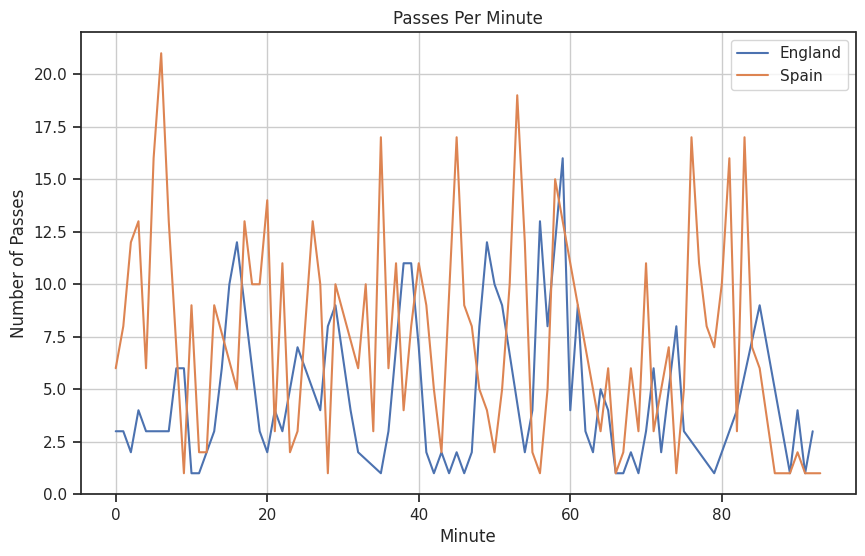

In [ ]:
#Passing tempo over the match, Spain vs England
passes_df = events_df[events_df["type"] == "Pass"].copy()

passes_per_minute = (
    passes_df.groupby(["team", passes_df["minute"]])
    .size()
    .reset_index(name="num_passes")
)

plt.figure(figsize=(10,6))

for team in passes_per_minute["team"].unique():
    team_data = passes_per_minute[passes_per_minute["team"] == team]
    plt.plot(team_data["minute"], team_data["num_passes"], label=team)

plt.title("Passes Per Minute")
plt.xlabel("Minute")
plt.ylabel("Number of Passes")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Successful pass dataset
passes_df = events_df[
    (events_df["type"] == "Pass") &
    (events_df["pass_outcome"].isna())
].copy()

passes_df["passer"] = passes_df["player"]
passes_df["receiver"] = passes_df["pass_recipient"]

In [ ]:
#Aggregate pass between players
pass_edges = (
    passes_df.groupby(["team", "passer", "receiver"])
    .size()
    .reset_index(name="pass_count")
)

In [ ]:
#Building the pass network graph
import networkx as nx

team_name = "Spain"
team_passes = pass_edges[pass_edges["team"] == team_name]

G = nx.DiGraph()

for _, row in team_passes.iterrows():
    G.add_edge(row["passer"], row["receiver"], weight=row["pass_count"])

In [ ]:
centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, normalized=True, weight="weight")

import pandas as pd

network_stats = pd.DataFrame({
    "player": list(centrality.keys()),
    "degree_centrality": list(centrality.values()),
    "betweenness": list(betweenness.values())
}).sort_values(by="betweenness", ascending=False)

network_stats.head(10)

#degree centrality → Involvement in circulation

#betweenness → “Connector” role in transitions

,player,degree_centrality,betweenness
5,Martín Zubimendi Ibáñez,1.538462,0.248001
1,Daniel Olmo Carvajal,1.615385,0.244689
10,Álvaro Borja Morata Martín,1.230769,0.164698
12,Mikel Oyarzabal Ugarte,0.538462,0.139057
3,Lamine Yamal Nasraoui Ebana,1.153846,0.087485
4,Marc Cucurella Saseta,1.230769,0.081410
8,Rodrigo Hernández Cascante,1.153846,0.039209
13,José Ignacio Fernández Iglesias,0.384615,0.037927
11,Daniel Carvajal Ramos,1.461538,0.030128
9,Unai Simón Mendibil,0.923077,0.028266


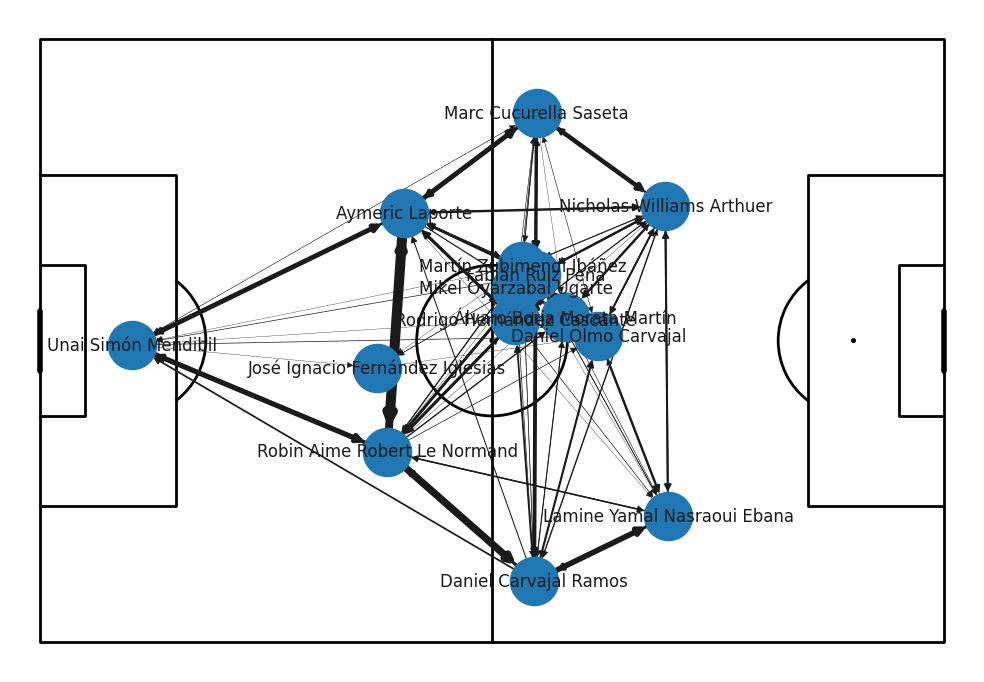

In [ ]:
#Visualization
from mplsoccer import Pitch

pitch = Pitch(line_color="black")
fig, ax = pitch.draw(figsize=(10,7))

avg_locations = (
    passes_df[passes_df["team"] == team_name]
    .groupby("player")[["x","y"]]
    .mean()
)

pos_dict = {
    player: (row["x"], row["y"])
    for player, row in avg_locations.iterrows()
}

nx.draw(
    G,
    pos=pos_dict,
    with_labels=True,
    node_size=1200,
    width=[d["weight"] * 0.25 for (_, _, d) in G.edges(data=True)],
    ax=ax
)